# Crack Network Generator - Usage Guide

## Installation

Required packages:
```bash
pip install numpy networkx matplotlib scipy
```

## Quick Start

```python
from crack_network_generator import CrackNetworkGenerator
import matplotlib.pyplot as plt

mm = 1e-3

# Create generator
generator = CrackNetworkGenerator(
    domain_size=(20*mm, 20*mm),
    seed=42  # For reproducibility
)

# Generate network
generator.generate_network(
    n_junctions=5,
    n_tips=20,
    edge_length_mean=3*mm,
    edge_length_std=1*mm,
    allow_intersections=False,
    min_junction_angle_deg=45.0,
    min_edge_distance=1.0*mm
)

# Visualize
fig, ax = generator.visualize(node_size=80, edge_width=1.5)
plt.show()

# Export to arrays
vertices, connectivity = generator.to_arrays()
```

## All Parameters

### Basic Network Structure
- `n_junctions`: Number of junction vertices (degree ≥ 3)
- `n_tips`: Number of tip vertices (degree = 1)
- `max_junction_order`: Maximum junction degree (3-6 typical)

### Edge Properties
- `edge_length_mean`: Mean edge length (m)
- `edge_length_std`: Std deviation of edge length (m)
- `min_edge_length`: Minimum edge length (m)
- `max_edge_length`: Maximum edge length (m)

### Spatial Distribution
- `spatial_distribution`: 'uniform', 'clustered', or 'grid'
- `connection_strategy`: 'nearest_neighbor', 'delaunay', or 'random'

### Geometric Constraints
- `allow_intersections`: If False, prevents edge crossings (default: False)
- `min_junction_angle_deg`: Minimum angle between edges at junctions (degrees, default: 30)
- `min_edge_distance`: Minimum distance between parallel edges (m, default: 0)

### Connected Crack Paths (NEW!)
- `n_crack_paths`: Number of polyline cracks (default: 0)
- `segments_per_path_mean`: Average segments per path
- `segments_per_path_std`: Std deviation of segments per path
- `path_angle_change_mean_deg`: Systematic curvature (0° = straight)
- `path_angle_change_std_deg`: Random wiggle (10-45° typical)

## Example Use Cases

### 1. Junction Network with Constraints
```python
generator.generate_network(
    n_junctions=10,
    n_tips=30,
    edge_length_mean=4*mm,
    edge_length_std=1.5*mm,
    max_junction_order=4,
    
    # Prevent crowding
    allow_intersections=False,
    min_junction_angle_deg=40.0,
    min_edge_distance=1.0*mm,
    
    spatial_distribution='uniform',
    connection_strategy='nearest_neighbor'
)
```

### 2. Long Straight Propagating Cracks
```python
generator.generate_network(
    n_junctions=0,  # No junctions
    n_tips=0,       # No isolated tips
    
    edge_length_mean=2*mm,
    edge_length_std=0.5*mm,
    
    # Create long paths
    n_crack_paths=8,
    segments_per_path_mean=20,
    segments_per_path_std=5,
    path_angle_change_mean_deg=0.0,   # Straight
    path_angle_change_std_deg=10.0,   # Small wiggle
    
    allow_intersections=False,
    min_edge_distance=1.5*mm
)
```

### 3. Curved/Tortuous Cracks
```python
generator.generate_network(
    n_junctions=0,
    n_tips=0,
    
    edge_length_mean=1.5*mm,
    edge_length_std=0.3*mm,
    
    n_crack_paths=10,
    segments_per_path_mean=15,
    segments_per_path_std=5,
    path_angle_change_mean_deg=5.0,   # Slight curve
    path_angle_change_std_deg=25.0,   # High variation
    
    allow_intersections=True,  # Allow coalescence
    spatial_distribution='clustered'
)
```

### 4. Mixed Network (Junctions + Long Cracks)
```python
generator.generate_network(
    # Junction network
    n_junctions=5,
    n_tips=20,
    max_junction_order=4,
    
    edge_length_mean=3*mm,
    edge_length_std=1*mm,
    
    # Add long cracks
    n_crack_paths=8,
    segments_per_path_mean=10,
    segments_per_path_std=3,
    path_angle_change_mean_deg=0.0,
    path_angle_change_std_deg=20.0,
    
    allow_intersections=False,
    min_junction_angle_deg=45.0,
    min_edge_distance=0.8*mm
)
```

## Visualization Options

### Standard Visualization
```python
fig, ax = generator.visualize(
    figsize=(12, 10),
    show_labels=False,        # Hide vertex IDs
    show_edge_labels=False,   # Hide edge lengths
    node_size=100,            # Circle size
    edge_width=1.5,           # Line thickness
    edge_color='black'        # Line color
)
plt.show()
```

### Path Coloring (Shows Connected Components)
```python
fig, ax = generator.visualize_with_paths(figsize=(14, 14))
plt.show()
```

## Export to Arrays

```python
# Get arrays in your format
vertices, connectivity = generator.to_arrays()

# vertices: (n_vertices, 3) array with [id, x, y]
# connectivity: (n_edges, 3) array with [edge_id, v0, v1]

# Use with your CrackNetworkV4
from your_module import CrackNetworkV4

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    degrees="auto",
    validate=True
)
```

## Statistics

```python
generator.print_statistics()
# Prints:
# - Vertex counts by type (tips, kinks, junctions)
# - Edge statistics (count, length distribution)
# - Degree distribution
# - Connected components
```

## Typical Parameter Ranges

| Parameter | Conservative | Moderate | Aggressive |
|-----------|-------------|----------|------------|
| `min_junction_angle_deg` | 60° | 40° | 30° |
| `min_edge_distance` | 2mm | 1mm | 0.5mm |
| `segments_per_path_mean` | 5 | 10 | 20 |
| `path_angle_change_std_deg` | 10° | 25° | 45° |

## Tips

1. **Start simple**: Begin with just junctions/tips, then add paths
2. **Constraints trade-off**: Stricter constraints may result in fewer edges
3. **Seed for reproducibility**: Always set a seed if you need to regenerate
4. **Check statistics**: Use `print_statistics()` to verify network properties
5. **Path angles**: 
   - Straight: `mean=0°, std=10°`
   - Curved: `mean=5°, std=20°`
   - Jagged: `mean=0°, std=40°`

## Troubleshooting

**Problem**: Not enough edges created
- **Solution**: Relax constraints (lower min_angle, lower min_distance)
- Or increase `max_angle_attempts` in the code

**Problem**: Edges too close together
- **Solution**: Increase `min_edge_distance`

**Problem**: Sharp angles at junctions
- **Solution**: Increase `min_junction_angle_deg`

**Problem**: Paths terminate early
- **Solution**: Increase domain size or reduce segment length


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# Ensure project root is on path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import graph_utils.crack_network_generator  as gen
importlib.reload(gen)
from graph_utils.crack_network_generator import *


# ============================================================================
# USAGE EXAMPLE
# ============================================================================

# Create generator
mm = 1e-3
generator = gen.CrackNetworkGenerator(
    domain_size=(100*mm, 100*mm),
    seed=42  # For reproducibility
)

# Generate network
generator.generate_network(
    n_junctions=0,           # Number of junction vertices
    n_tips=20,                # Number of tip vertices
    edge_length_mean=40*mm,   # Mean edge length
    edge_length_std=5*mm,    # Std dev of edge length
    max_junction_order=3,    # Max junction degree (3-4 typical)
    spatial_distribution='uniform',  # 'uniform', 'clustered', 'grid'
    connection_strategy='nearest_neighbor',  # 'nearest_neighbor', 'delaunay', 'random'
    min_edge_length=5*mm,
    max_edge_length=20*mm
)

# Print statistics
generator.print_statistics()

# Visualize
fig, ax = generator.visualize(
    figsize=(12, 10),
    show_labels=False,
    show_edge_labels=False,
    node_size=10,
    edge_color='blue',
    edge_width=2.0
)
plt.show()

# Export to your format
vertices, connectivity = generator.to_arrays()

print("\n" + "="*60)
print("EXPORTED ARRAYS")
print("="*60)
print("\nvertices =")
print(vertices)
print("\nconnectivity =")
print(connectivity)

# Use with your CrackNetworkV4
# net = CrackNetworkV4.from_vertices_connectivity(
#     vertices=vertices,
#     connectivity=connectivity,
#     Nv_max=3,
#     degrees="auto",
#     validate=True,
# )

ModuleNotFoundError: No module named 'graph_utils'

CRACK NETWORK STATISTICS

Vertices:
  Total: 110
  Tips (degree 1): 100
  Kinks (degree 2): 0
  Junctions (degree 3+): 10

Edges:
  Total: 65
  Length range: [1.03, 2.98] mm
  Mean length: 2.22 mm
  Std dev: 0.54 mm

Degree distribution:
  Degree 1: 100 vertices
  Degree 3: 10 vertices

Connected components (paths): 45


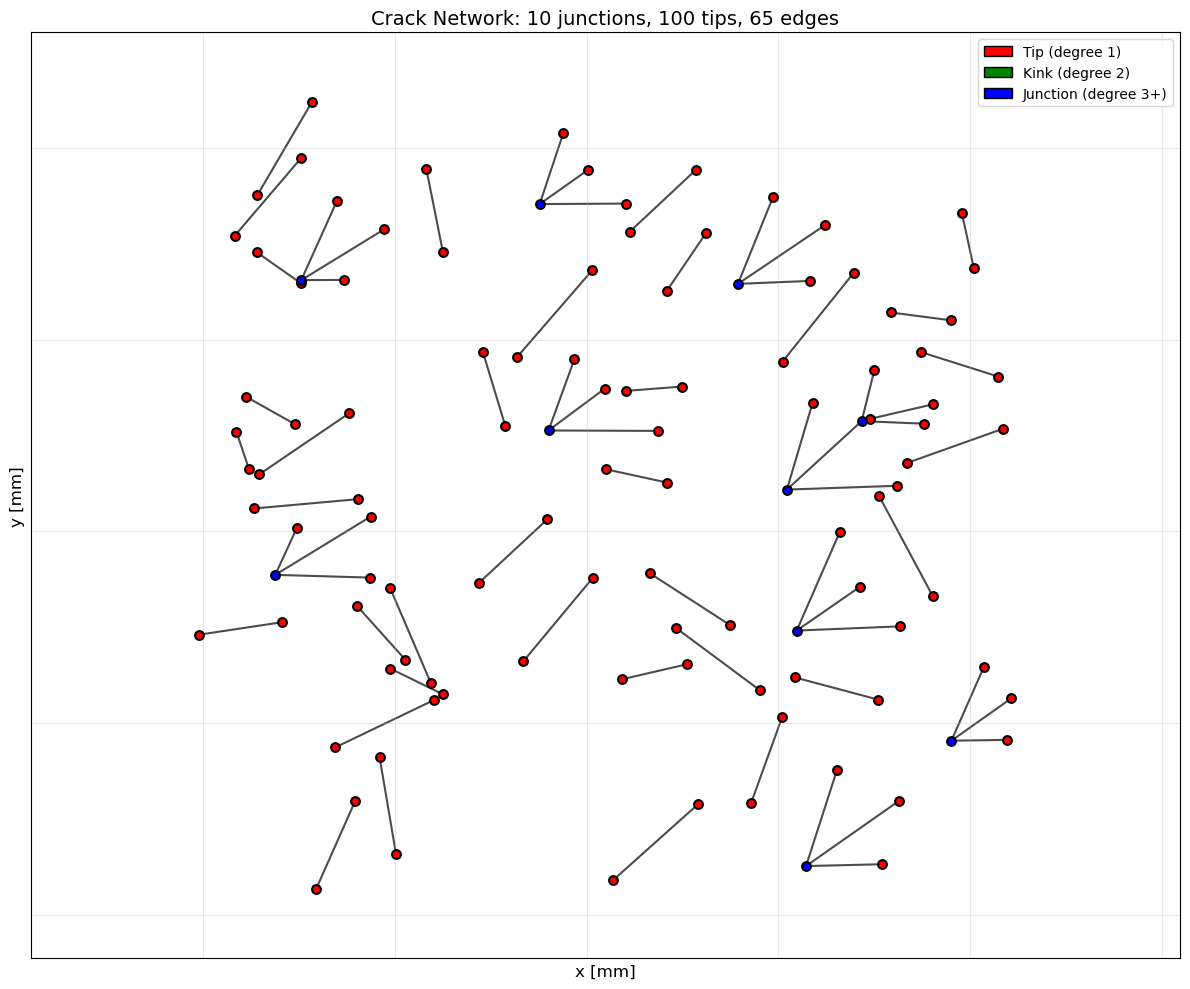


EXPORTED ARRAYS

vertices = np.array([
    [ 0.          0.00547912 -0.00258404],
    [ 1.         -0.00122243  0.0085353 ],
    [2.         0.00717196 0.0028773 ],
    [3.         0.00394736 0.00645523],
    [ 4.00000000e+00 -8.11645304e-03 -1.13171602e-03],
    [ 5.          0.00951245 -0.00545523],
    [6.00000000e+00 5.22279404e-03 1.09169574e-03],
    [ 7.00000000e+00  5.72128611e-03 -8.72365488e-03],
    [ 8.00000000e+00 -7.43772735e-03  6.55262344e-03],
    [ 9.00000000e+00 -9.92281242e-04  2.63328798e-03],
    [ 1.00000000e+01  8.16612027e-03 -2.47435467e-03],
    [ 1.10000000e+01  7.12653594e-03 -1.44392097e-03],
    [ 1.20000000e+01  6.60085061e-03 -1.60565112e-05],
    [1.30000000e+01 1.03465099e-03 8.54883973e-03],
    [1.40000000e+01 3.32777164e-05 9.42426082e-03],
    [ 1.50000000e+01 -6.03781000e-04  1.03917959e-02],
    [1.60000000e+01 8.78906153e-03 2.80990909e-03],
    [1.70000000e+01 7.50484573e-03 4.21229519e-03],
    [1.80000000e+01 5.81735662e-03 6.53183900e-03],

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# Ensure project root is on path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import graph_utils.crack_network_generator  as gen
importlib.reload(gen)
from graph_utils.crack_network_generator import *

# ============================================================================
# USAGE EXAMPLE
# ============================================================================

if __name__ == "__main__":
    # Create generator
    mm = 1e-3
    generator = CrackNetworkGenerator(
        domain_size=(20*mm, 20*mm),
        seed=42  # For reproducibility
    )
    
    # Generate network WITHOUT intersections
    generator.generate_network(
        n_junctions=10,           # Number of junction vertices
        n_tips=100,               # Number of tip vertices
        edge_length_mean=5*mm,   # Mean edge length
        edge_length_std=2*mm,    # Std dev of edge length
        max_junction_order=3,    # Max junction degree (3-4 typical)
        spatial_distribution='uniform',  # 'uniform', 'clustered', 'grid'
        connection_strategy='nearest_neighbor',  # 'nearest_neighbor', 'delaunay', 'random'
        min_edge_length=1*mm,
        max_edge_length=3*mm,
        allow_intersections=False  # ← Prevent edge crossings
    )
    
    # Print statistics
    generator.print_statistics()
    
    # Visualize
    fig, ax = generator.visualize(
        figsize=(12, 10),
        show_labels=False,
        show_edge_labels=False,
        node_size=40,
        edge_width=1.5,
        edge_color='black'
    )
    plt.show()
    
    # Export to arrays
    vertices, connectivity = generator.to_arrays()
    
    print("\n" + "="*60)
    print("EXPORTED ARRAYS")
    print("="*60)
    print("\nvertices = np.array([")
    for row in vertices:
        print(f"    {row},")
    print("], dtype=float)")
    
    print("\nconnectivity = np.array([")
    for row in connectivity:
        print(f"    {row},")
    print("], dtype=int)")

Detecting edge intersections...
Found 3 intersection(s)
  Created junction node 53 at (-2.05, 5.86) mm
    Split edge (1, 2) into 1-53 and 53-2
    Split edge (45, 46) into 45-53 and 53-46
  Created junction node 54 at (-5.87, 0.49) mm
    Split edge (4, 5) into 4-54 and 54-5
    Split edge (40, 41) into 40-54 and 54-41
  Created junction node 55 at (0.28, -5.62) mm
    Split edge (12, 13) into 12-55 and 55-13
    Split edge (23, 24) into 23-55 and 55-24
Successfully processed 3 intersection(s)


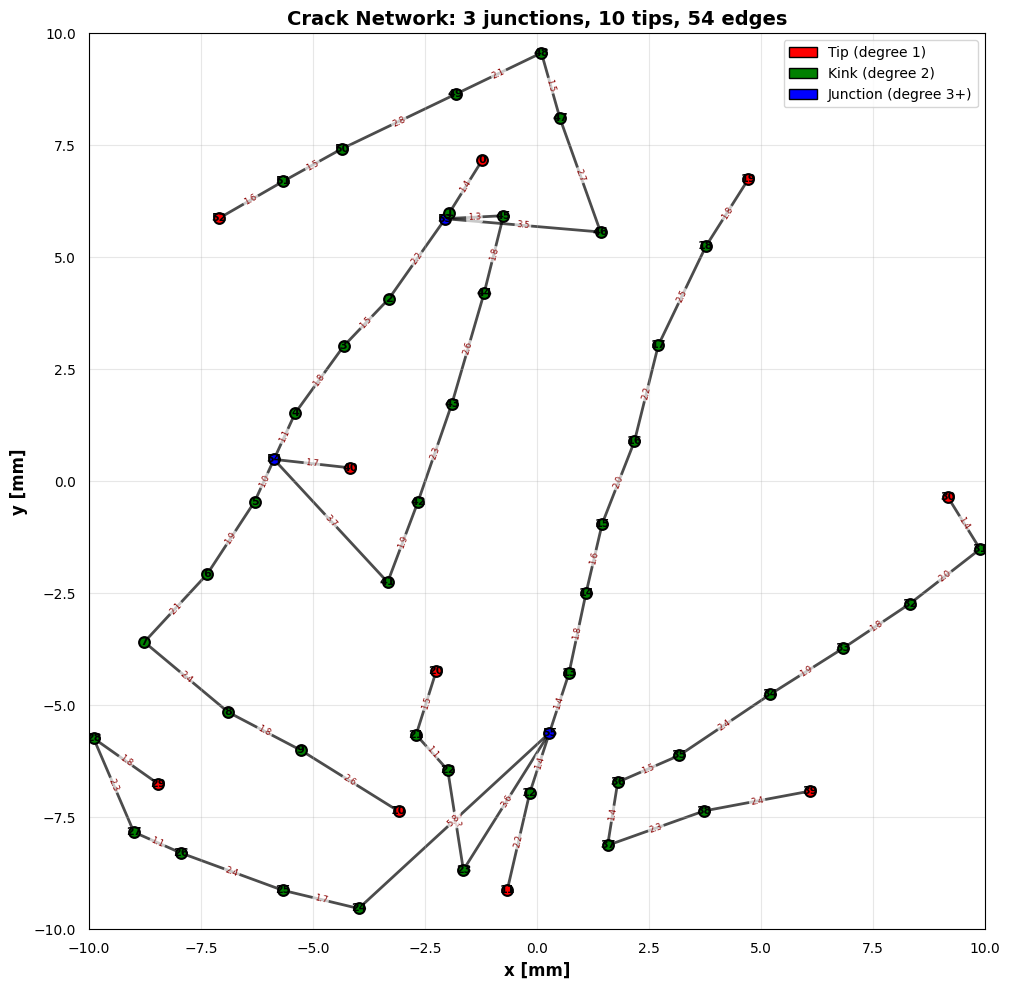

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# Ensure project root is on path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

from fracture_utils.Ugenerator.crack_network_generator_v1 import CrackNetworkGenerator


mm = 1e-3

generator = CrackNetworkGenerator(
    domain_size=(20*mm, 20*mm),
    seed=42
)

generator.generate_network(
    n_junctions=0,              # No junctions
    n_tips=0,                   # No isolated tips
    edge_length_mean=2*mm,
    edge_length_std=0.5*mm,
    min_edge_length=1*mm,
    max_edge_length=3*mm,
    
    # Connected crack paths
    n_crack_paths=5,                    # 5 long cracks
    segments_per_path_mean=10,          # Average 10 segments each
    segments_per_path_std=3,            # ±3 segments variation
    path_angle_change_mean_deg=0.0,     # Straight (no systematic curvature)
    path_angle_change_std_deg=10.0,     # Small random wiggles (±10°)
    
    allow_intersections=True,
    detect_intersections=True,
    min_edge_distance=1.0*mm
)

fig, ax = generator.visualize(node_size=60, edge_width=2.0)
plt.show()

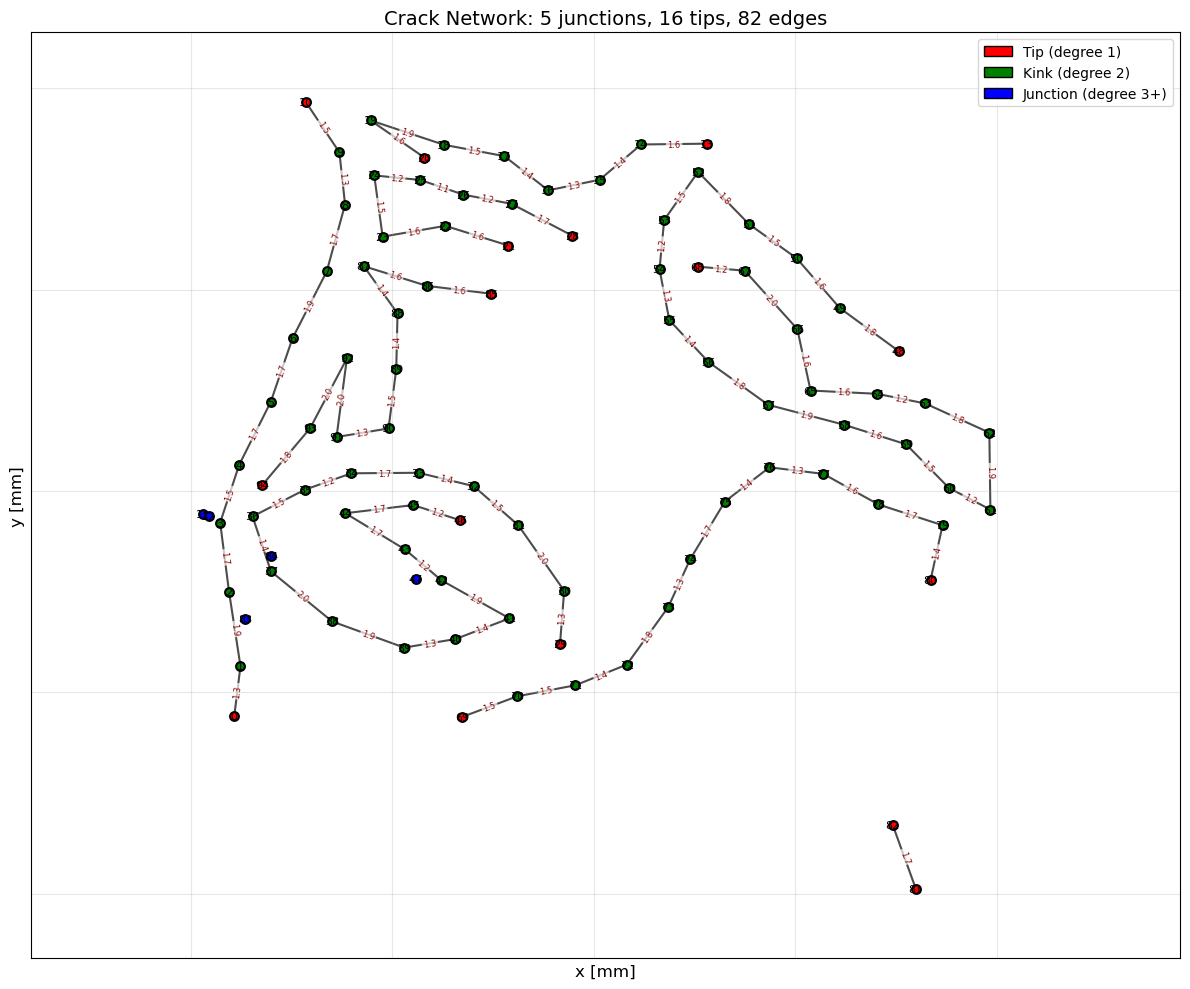

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# Ensure project root is on path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import graph_utils.crack_network_generator  as gen
importlib.reload(gen)
from graph_utils.crack_network_generator import *

generator = CrackNetworkGenerator(
    domain_size=(20*mm, 20*mm),
    seed=123
)

generator.generate_network(
    n_junctions=0,
    n_tips=0,
    edge_length_mean=1.5*mm,
    edge_length_std=0.3*mm,
    min_edge_length=1*mm,
    max_edge_length=2*mm,
    
    # Curved paths
    n_crack_paths=8,
    segments_per_path_mean=15,          # Longer paths
    segments_per_path_std=5,
    path_angle_change_mean_deg=5.0,     # Slight systematic curve
    path_angle_change_std_deg=20.0,     # Moderate wiggle
    
    allow_intersections=False,
    min_edge_distance=0.5*mm
)

fig, ax = generator.visualize(node_size=40, edge_width=1.5)
plt.show()

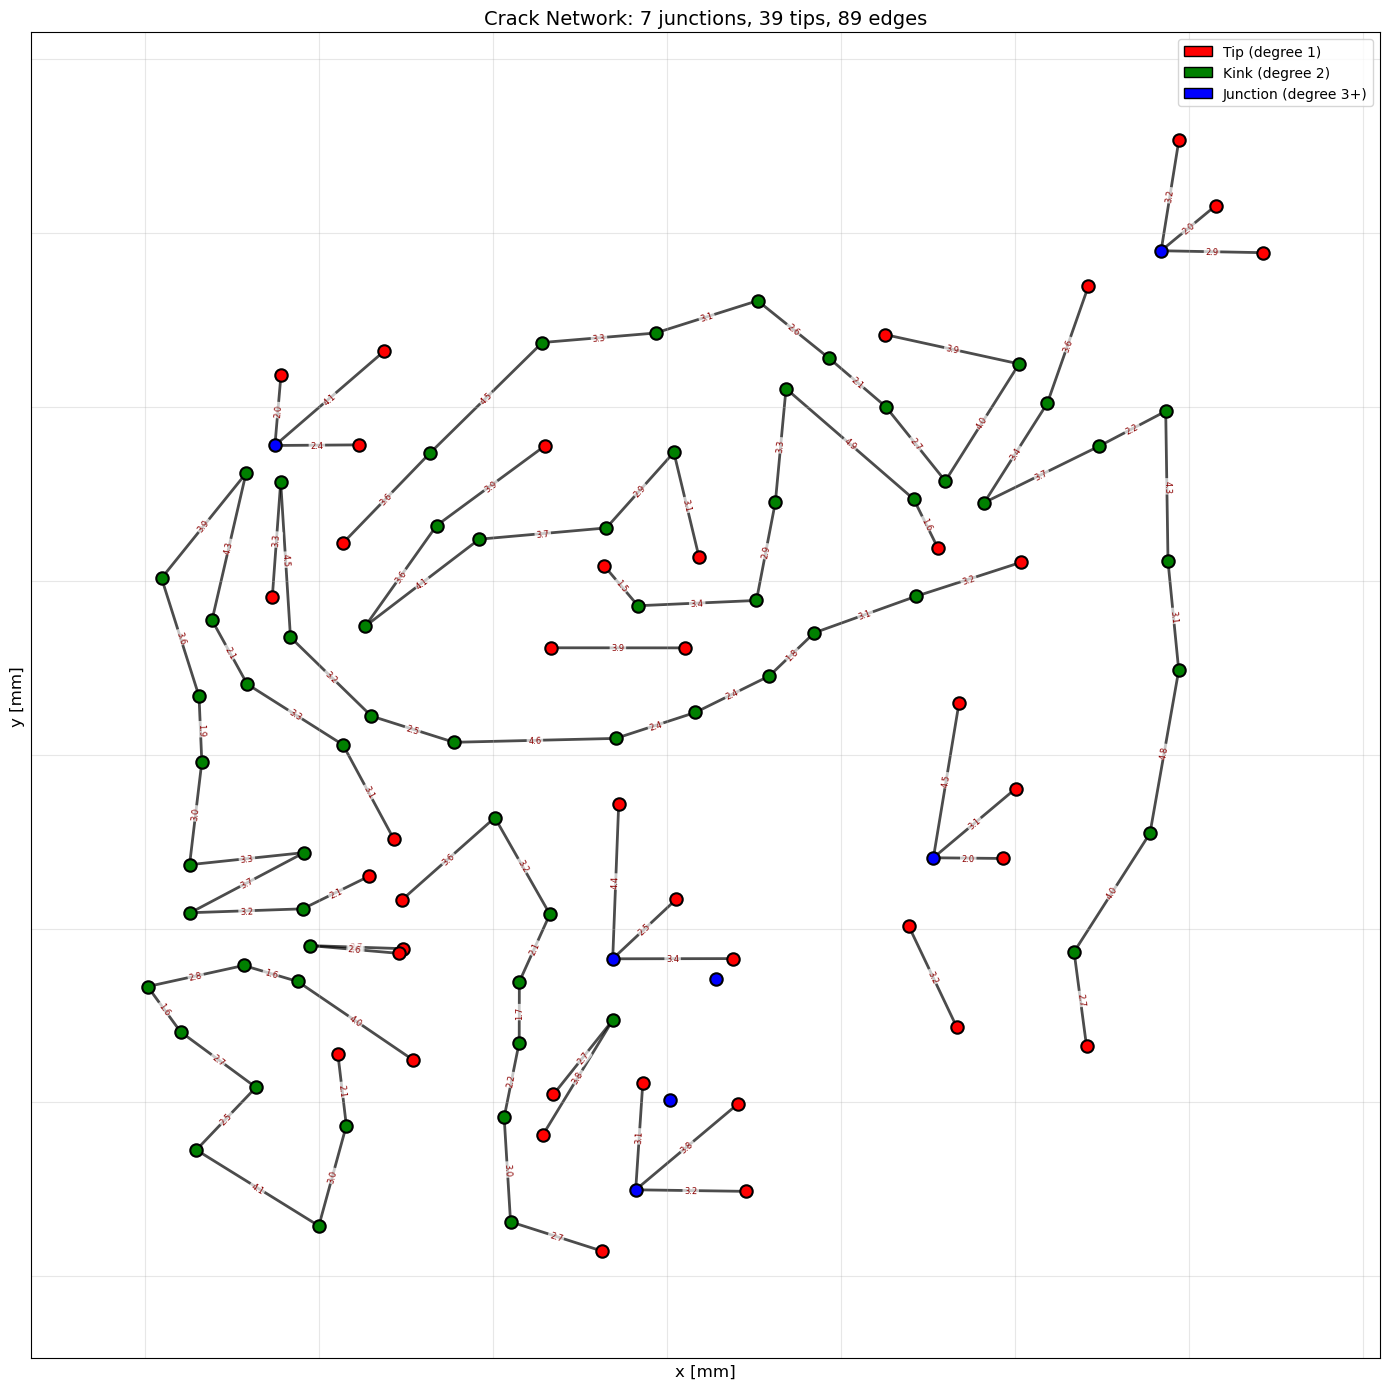

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# Ensure project root is on path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import graph_utils.crack_network_generator  as gen
importlib.reload(gen)
from graph_utils.crack_network_generator import *

generator = CrackNetworkGenerator(
    domain_size=(30*mm, 30*mm),
    seed=456
)

generator.generate_network(
    # Junction network
    n_junctions=5,
    n_tips=20,
    max_junction_order=4,
    
    # Edge properties
    edge_length_mean=3*mm,
    edge_length_std=1*mm,
    min_edge_length=1.5*mm,
    max_edge_length=5*mm,
    
    # Add long connected cracks
    n_crack_paths=10,                   # 10 polyline cracks
    segments_per_path_mean=8,           # 8 segments each on average
    segments_per_path_std=3,
    path_angle_change_mean_deg=0.0,     # No systematic curvature
    path_angle_change_std_deg=25.0,     # Random direction changes
    
    # Constraints
    allow_intersections=False,
    min_junction_angle_deg=40.0,
    min_edge_distance=1.0*mm,
    
    spatial_distribution='uniform',
    connection_strategy='nearest_neighbor'
)

fig, ax = generator.visualize(
    figsize=(14, 14),
    node_size=80,
    edge_width=2.0,
    show_labels=False
)
plt.show()

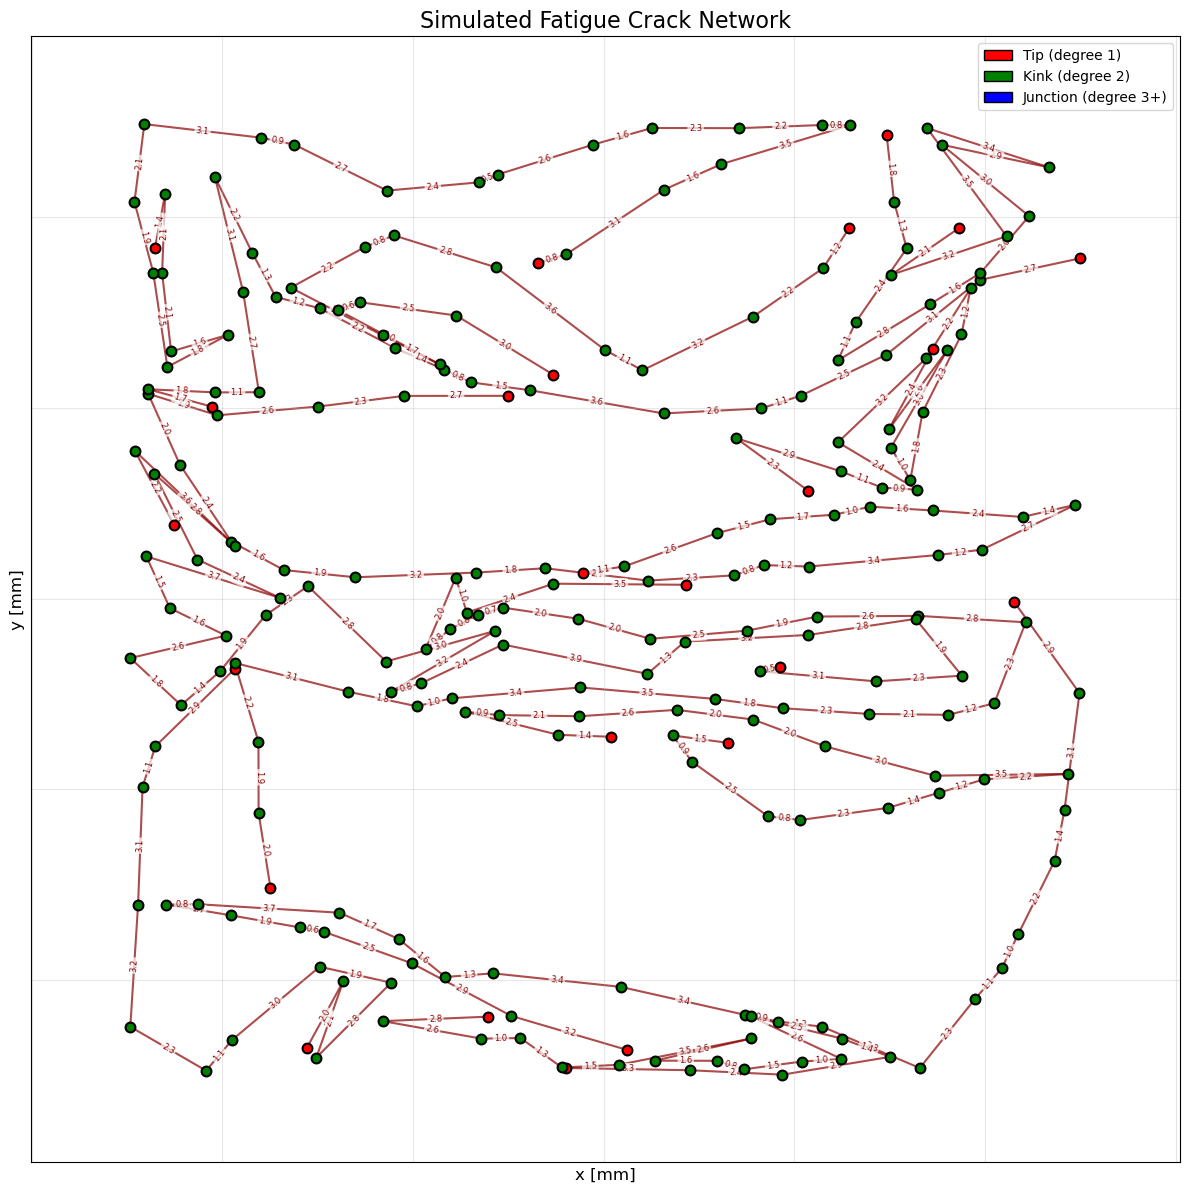

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# Ensure project root is on path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import graph_utils.crack_network_generator  as gen
importlib.reload(gen)
from graph_utils.crack_network_generator import *

# Simulate fatigue cracks with gradual growth
generator = CrackNetworkGenerator(
    domain_size=(25*mm, 25*mm),
    seed=789
)

generator.generate_network(
    n_junctions=0,
    n_tips=0,
    
    # Variable segment lengths (crack slows down)
    edge_length_mean=2*mm,
    edge_length_std=1*mm,
    min_edge_length=0.5*mm,
    max_edge_length=4*mm,
    
    # Long propagating cracks
    n_crack_paths=12,
    segments_per_path_mean=20,          # Very long cracks
    segments_per_path_std=8,
    path_angle_change_mean_deg=2.0,     # Slight systematic turn
    path_angle_change_std_deg=15.0,     # Moderate randomness
    
    allow_intersections=False,           # Allow crack coalescence
    min_edge_distance=0.0,              # Allow proximity
    
    spatial_distribution='clustered'    # Clustered nucleation
)

fig, ax = generator.visualize(
    figsize=(12, 12),
    node_size=50,
    edge_width=1.5,
    show_labels=False,
    edge_color='darkred'
)
ax.set_title('Simulated Fatigue Crack Network', fontsize=16, weight='bold')
plt.show()

CRACK NETWORK STATISTICS

Vertices:
  Total: 10
  Tips (degree 1): 6
  Kinks (degree 2): 4
  Junctions (degree 3+): 0

Edges:
  Total: 7
  Length range: [2.57, 4.08] mm
  Mean length: 3.31 mm
  Std dev: 0.53 mm

Degree distribution:
  Degree 1: 6 vertices
  Degree 2: 4 vertices

Connected components (paths): 3
  Path 1: 3 vertices, 2 edges
  Path 2: 4 vertices, 3 edges
  Path 3: 3 vertices, 2 edges


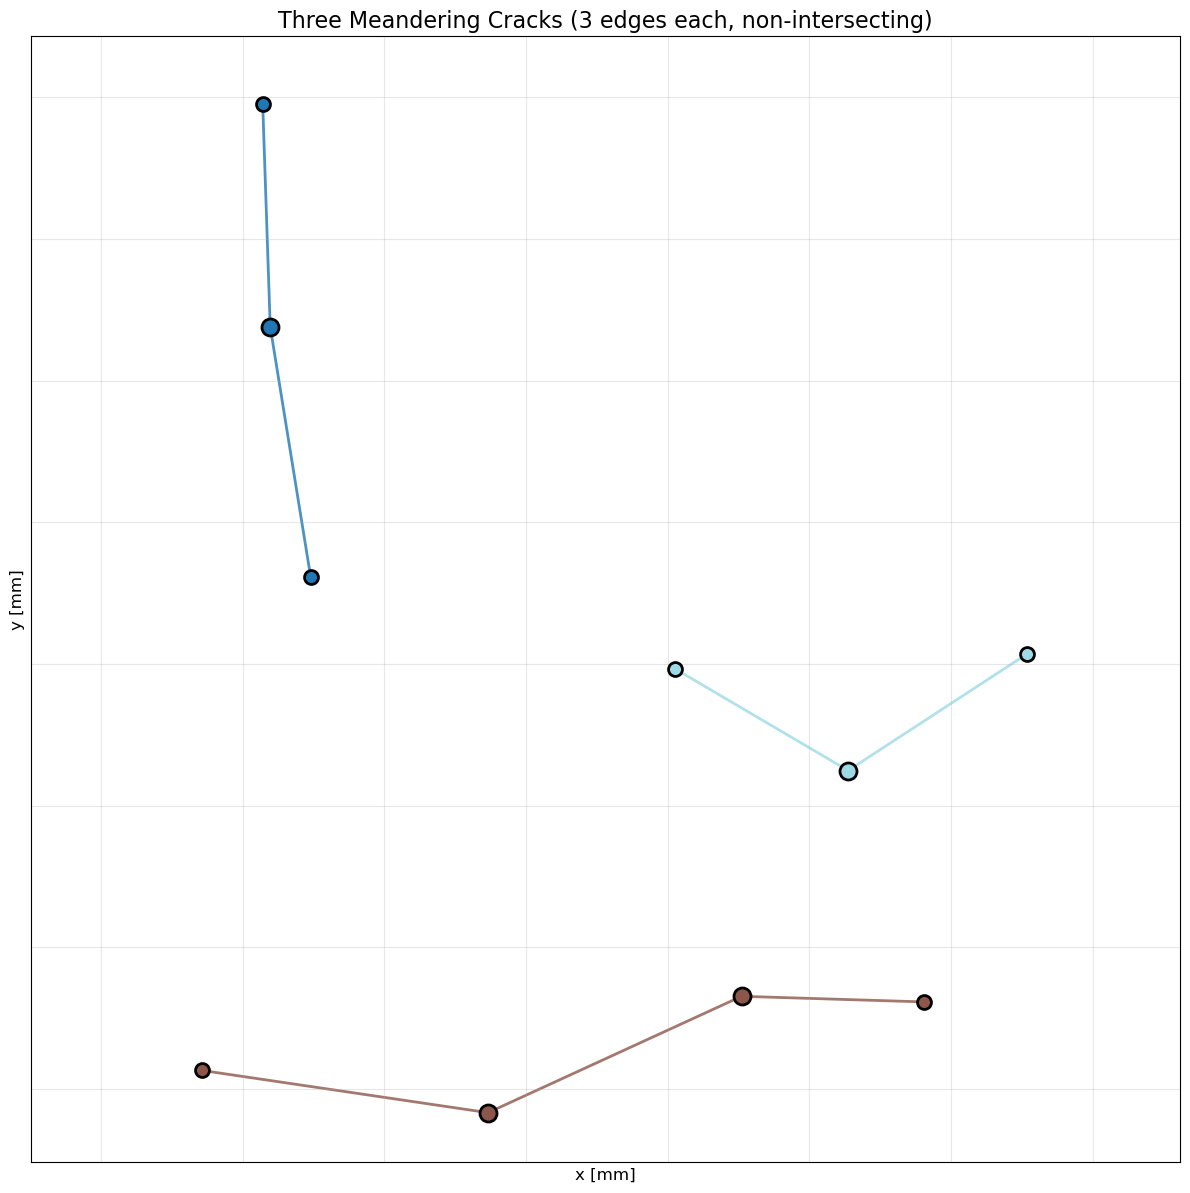

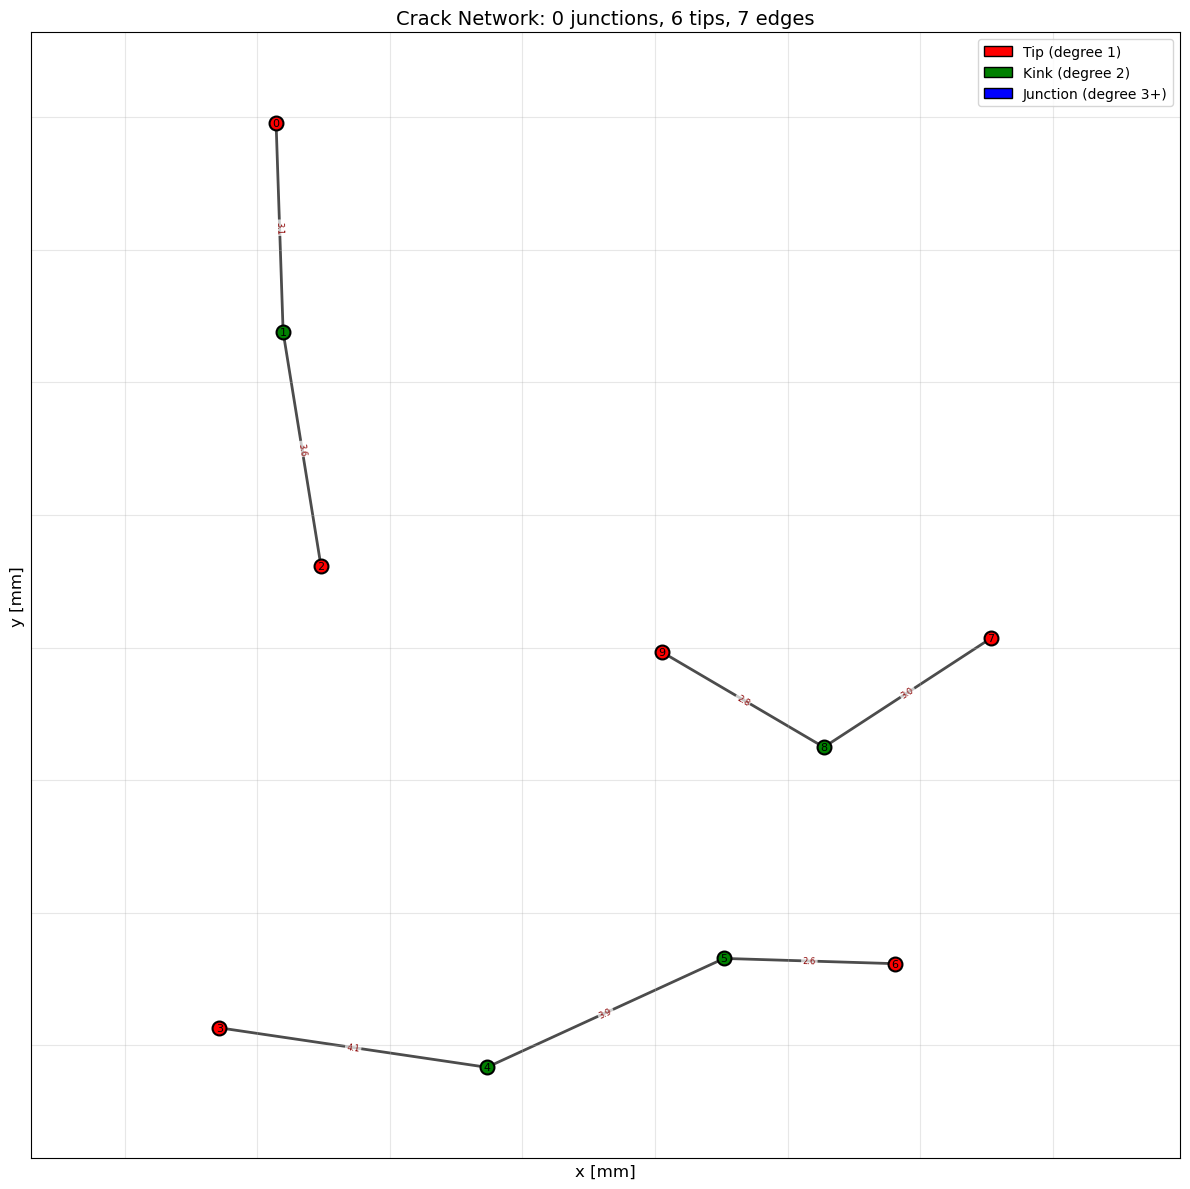


Exported arrays:
  Vertices shape: (10, 3)
  Connectivity shape: (7, 3)

First few vertices (id, x[mm], y[mm]):
[[ 0.          0.28318882 11.90609264]
 [ 1.          0.38925838  8.76000644]
 [ 2.          0.95971247  5.23172803]
 [ 3.         -0.5711619  -1.73759306]
 [ 4.          3.46382101 -2.33323378]]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# Ensure project root is on path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import graph_utils.crack_network_generator  as gen
importlib.reload(gen)
from graph_utils.crack_network_generator import *

mm=1e-3
# Generate exactly 3 non-intersecting meandering cracks, each with 3 edges
generator = CrackNetworkGenerator(
    domain_size=(25*mm, 25*mm),
    seed=4  # Change seed for different patterns
)

generator.generate_network(
    n_junctions=0,
    n_tips=0,
    
    # Edge properties for meandering
    edge_length_mean=3*mm,
    edge_length_std=0.5*mm,
    min_edge_length=2*mm,
    max_edge_length=6*mm,
    
    # Exactly 3 cracks, each with 3 segments
    n_crack_paths=3,
    segments_per_path_mean=3,
    segments_per_path_std=1,  # Some variation in segments per path
    
    # Small random angles for meandering
    path_angle_change_mean_deg=0.0,     # No systematic turn
    path_angle_change_std_deg=30.0,     # Small random angles (±30°)
    
    # Non-intersecting
    allow_intersections=False,
    min_edge_distance=1.0*mm,  # Keep cracks separated
    
    spatial_distribution='uniform'
)

# Print statistics
generator.print_statistics()

# Visualize with path coloring to see the 3 separate cracks
fig, ax = generator.visualize_with_paths(figsize=(12, 12))
ax.set_title('Three Meandering Cracks (3 edges each, non-intersecting)', 
             fontsize=16, weight='bold')
plt.show()

# Also show standard visualization
fig2, ax2 = generator.visualize(
    figsize=(12, 12),
    node_size=100,
    edge_width=2.0,
    show_labels=True,
    show_edge_labels=True,
    edge_color='black'
)
plt.show()

# Export arrays for further analysis
vertices, connectivity = generator.to_arrays()
print(f"\nExported arrays:")
print(f"  Vertices shape: {vertices.shape}")
print(f"  Connectivity shape: {connectivity.shape}")
print(f"\nFirst few vertices (id, x[mm], y[mm]):")
print(vertices[:5] * [1, 1e3, 1e3])  # Convert to mm for display

Detecting edge intersections...
Found 4 intersection(s)
  Created junction node 35 at (15.15, 2.79) mm
    Split edge (0, 4) into 0-35 and 35-4
    Split edge (18, 19) into 18-35 and 35-19
  Created junction node 36 at (7.43, 1.87) mm
    Split edge (17, 18) into 17-36 and 36-18
    Split edge (31, 32) into 31-36 and 36-32
Successfully processed 2 intersection(s)
CRACK NETWORK STATISTICS

Vertices:
  Total: 37
  Tips (degree 1): 20
  Kinks (degree 2): 11
  Junctions (degree 3+): 6

Edges:
  Total: 32
  Length range: [0.76, 15.54] mm
  Mean length: 6.21 mm
  Std dev: 2.82 mm

Degree distribution:
  Degree 1: 20 vertices
  Degree 2: 11 vertices
  Degree 3: 2 vertices
  Degree 4: 4 vertices

Connected components (paths): 5
  Path 1: 22 vertices, 21 edges
  Path 2: 4 vertices, 3 edges
  Path 3: 4 vertices, 3 edges
  Path 4: 3 vertices, 2 edges
  Path 5: 4 vertices, 3 edges


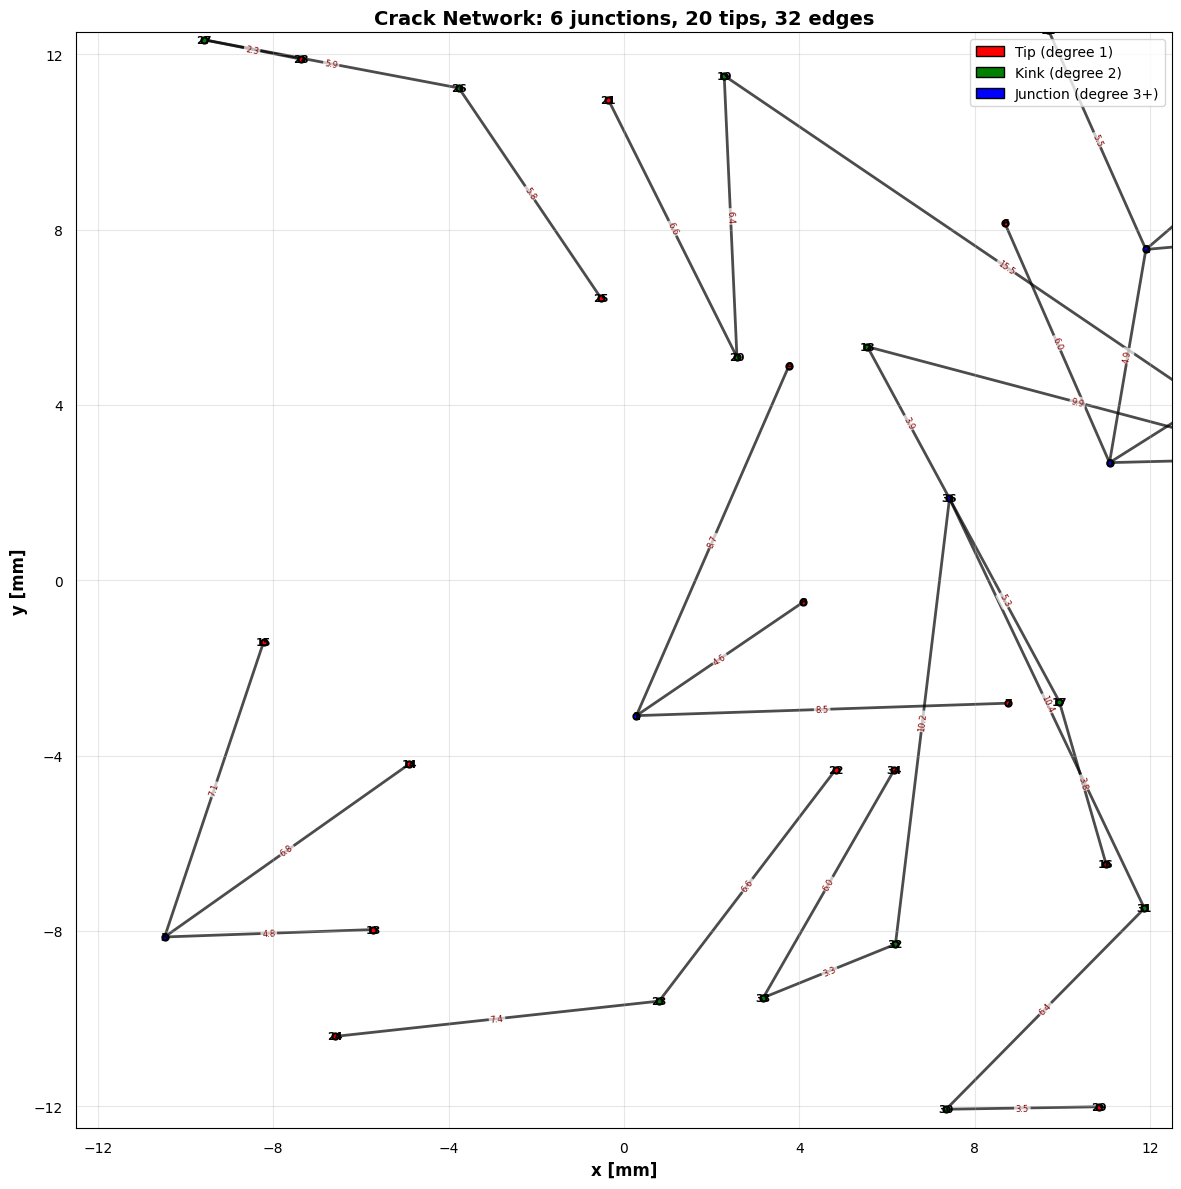

In [ ]:

from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

# --- Preamble re-exports
from preamble import *   
enable_autoreload()

# ----------------------------
# Helper: safe plotting calls
# ----------------------------
def _call(obj, name, *args, **kwargs):
    fn = getattr(obj, name, None)
    if fn is None:
        print(f"[skip] {obj.__class__.__name__}.{name} not found")
        return None
    try:
        return fn(*args, **kwargs)
    except TypeError as e:
        # In case signature differs slightly across versions
        print(f"[warn] {obj.__class__.__name__}.{name} signature mismatch: {e}")
        return fn(*args)

# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
generator = CrackNetworkGenerator(
    domain_size=(25*mm, 25*mm),
    seed=7  # Change seed for different patterns
)

generator.generate_network(
    n_junctions=3,
    n_tips=6,
    
    # Edge properties for meandering
    edge_length_mean=5*mm,
    edge_length_std=2*mm,
    min_edge_length=2*mm,
    max_edge_length=10*mm,

    # Exactly 4 cracks, each with 4 segments
    n_crack_paths=2,
    segments_per_path_mean=4,
    segments_per_path_std=2,  # Some variation in segments per path
    
    # Small random angles for meandering
    path_angle_change_mean_deg=0.0,     # No systematic turn
    path_angle_change_std_deg=10.0,     # Small random angles (±10°)

    # Non-intersecting
    allow_intersections=True,
    detect_intersections=True,
    min_edge_distance=1.0*mm,  # Keep cracks separated
    
    spatial_distribution='uniform'
)


# Print statistics
generator.print_statistics()

fig2, ax2 = generator.visualize(
    figsize=(12, 12),
    node_size=20,
    edge_width=2.0,
    show_labels=True,
    show_edge_labels=True,
    edge_color='black'
)
plt.show()
vertices, connectivity, vertex_types = generator.to_arrays()


